# 7. Dimensionless groups: Reynolds number and Dittus–Boelter

**Domain:** chemical engineering transport phenomena.

Transport correlations are written in dimensionless groups. The Reynolds number
compresses four measurements into one:

$$\mathrm{Re} = \frac{\rho v D}{\mu}$$

and turbulent pipe heat transfer follows Dittus–Boelter:

$$\mathrm{Nu} = 0.023\,\mathrm{Re}^{0.8}\,\mathrm{Pr}^{0.4}$$

**Goal:** build Re from raw $\rho, v, D, \mu$ without being told the grouping, then
recover the exponents 0.8 and 0.4.

This is the purest test of feature construction in engineering — dimensionless groups
are exactly the constructed features a discipline spent a century finding.

### The two-stage rule

`beamfeat` fits **ridge** regression (`alpha=1.0`) on *standardised* features. For a
single feature that shrinks the coefficient by about $n/(n+\alpha)$ — 0.2% at
$n=600$, but **7% at $n=13$**. Fine for prediction, fatal for measuring a constant.

So every notebook here runs two stages:

1. **`beamfeat` finds the form** — which combination of variables matters.
2. **OLS on that form estimates the constant** — unbiased.

Never read a physical constant off `.equation()`.


## Setup


In [1]:
%pip install -q "beamfeat[units]" pandas matplotlib seaborn scikit-learn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from beamfeat import BeamFeatRegressor, BeamFeatTransformer

warnings.filterwarnings("ignore", message=".*valid feature names.*")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_DIR = Path("csv")
CSV_DIR.mkdir(exist_ok=True)          # created on first run, reused after


def save_csv(frame, name):
    # Write to csv/<name> once, then read back so every run starts from disk.
    path = CSV_DIR / name
    if not path.exists():
        frame.to_csv(path, index=False)
        print(f"wrote  {path}  ({len(frame)} rows)")
    else:
        print(f"cached {path}")
    return pd.read_csv(path)


def raw_coef(m):
    # beamfeat standardises internally; rescale to original units.
    return m.coef_ / m.scaler_.scale_


def pct_err(est, true):
    return 100.0 * (est - true) / true

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(1)
N = 600


## Part A — constructing the Reynolds number

A simulated pipe-flow campaign: four properties varied independently, Reynolds number
measured. Nothing tells the search how they combine.


In [3]:
flow = pd.DataFrame({
    "rho": rng.uniform(700, 1100, N),      # kg/m^3
    "v":   rng.uniform(0.5, 6.0, N),       # m/s
    "D":   rng.uniform(0.01, 0.10, N),     # m
    "mu":  rng.uniform(3e-4, 2e-3, N),     # Pa.s
})
flow["Re"] = flow.rho * flow.v * flow.D / flow.mu

flow = save_csv(flow, "pipe_flow.csv")
flow.head()


wrote  csv/pipe_flow.csv  (600 rows)


,rho,v,D,mu,Re
0,904.728650,1.801432,0.049225,0.001984,40439.092257
1,1080.185479,0.692849,0.026137,0.001100,17774.822887
2,757.663845,4.736149,0.013329,0.001697,28185.249582
3,1079.459779,5.726951,0.079173,0.001122,436347.199243
4,824.732581,1.744363,0.017517,0.001706,14773.220903


### Look before you fit


In [4]:
print("missing:", int(flow.isna().sum().sum()))
print("min variance:", f"{flow.var().min():.3g}")
print(f"Re spans {flow.Re.min():,.0f} to {flow.Re.max():,.0f} "
      "(laminar through fully turbulent)")

flow.describe().T[["mean", "std", "min", "max"]]


missing: 0
min variance: 2.39e-07
Re spans 3,331 to 1,424,728 (laminar through fully turbulent)


,mean,std,min,max
rho,898.084380,113.986578,700.822737,1.099610e+03
v,3.368093,1.602966,0.520511,5.998851e+00
D,0.053677,0.025749,0.010009,9.971538e-02
mu,0.001127,0.000489,0.000307,1.993835e-03
Re,189725.417054,197166.681673,3330.711553,1.424728e+06


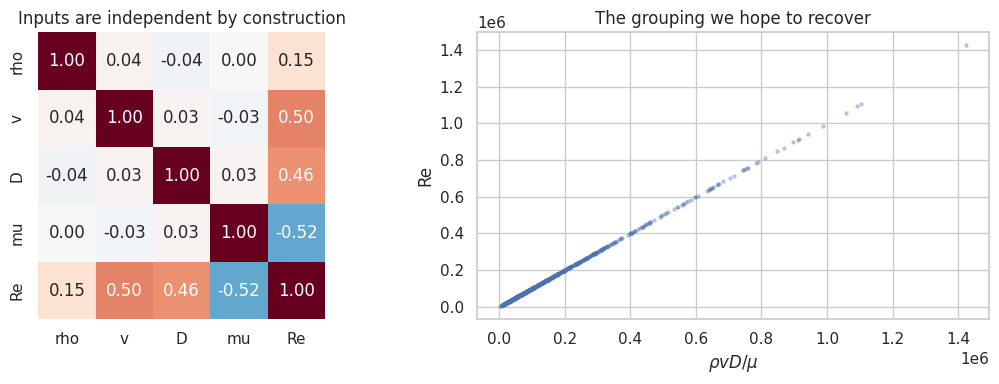

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(flow.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar=False, ax=ax[0])
ax[0].set_title("Inputs are independent by construction")

ax[1].scatter(flow.rho * flow.v * flow.D / flow.mu, flow.Re, s=5, alpha=.3)
ax[1].set_xlabel(r"$\rho v D / \mu$"); ax[1].set_ylabel("Re")
ax[1].set_title("The grouping we hope to recover")

plt.tight_layout()
plt.show()


Off-diagonal correlations near zero — a well-conditioned design. No single input
predicts Re; only the four-way grouping does.


In [6]:
X = flow[["rho", "v", "D", "mu"]].values     # x0=rho, x1=v, x2=D, x3=mu
Re = flow.Re.values

model = BeamFeatRegressor(max_depth=2, beam_width=40, random_state=0).fit(X, Re)

print("discovered :", model.formulas())
print(f"R^2        : {model.score(X, Re):.6f}")


discovered : ['((x2 / x3) * (x0 * x1))']
R^2        : 0.999997


Read it: `(x2 / x3) * (x0 * x1)` is $(D/\mu)(\rho v) = \rho v D/\mu$.

The Reynolds number, reconstructed exactly from four raw measurements.


## Part B — the exponents, and why you must log-transform

Power laws become linear under logarithms:

$$\ln \mathrm{Nu} = \ln 0.023 + 0.8 \ln \mathrm{Re} + 0.4 \ln \mathrm{Pr}$$

Before doing that, look at what happens if you skip it.


In [7]:
ht = pd.DataFrame({"Re": Re, "Pr": rng.uniform(2, 12, N)})
ht["Nu"] = 0.023 * ht.Re ** 0.8 * ht.Pr ** 0.4 * (1 + rng.normal(0, 0.03, N))
ht = save_csv(ht, "heat_transfer.csv")

Xdb = ht[["Re", "Pr"]].values
Nu = ht.Nu.values

direct = BeamFeatRegressor(max_depth=2, beam_width=40, random_state=0).fit(Xdb, Nu)
logged = BeamFeatRegressor(max_depth=2, beam_width=40,
                           random_state=0).fit(Xdb, np.log(Nu))

print(f"target Nu       : R^2 = {direct.score(Xdb, Nu):.4f}")
print(f"target log(Nu)  : R^2 = {logged.score(Xdb, np.log(Nu)):.4f}")

# What Re exponent does the direct fit actually imply?
implied = np.polyfit(np.log(Re), np.log(np.clip(direct.predict(Xdb), 1e-9, None)), 1)[0]
print(f"\nRe exponent implied by the direct fit : {implied:.3f}   (true 0.800)")


wrote  csv/heat_transfer.csv  (600 rows)
target Nu       : R^2 = 0.9958
target log(Nu)  : R^2 = 0.9983

Re exponent implied by the direct fit : 0.693   (true 0.800)


The direct fit reaches R² 0.996 and is still wrong: the exponent it implies is 0.69,
a 13% error. **A high R² on the raw scale does not mean you have the right power
law.** Log-transforming the target before hunting a power law is the single most
useful habit in this notebook.


## Judge a discovered basis by its span, not its appearance

The returned expressions look nothing like `log(Re)` and `log(Pr)`. That is usually
fine — what matters is whether the textbook coordinates can be reconstructed from
them. Check numerically.


In [8]:
tf = BeamFeatTransformer(max_depth=2, beam_width=40,
                         random_state=0).fit(Xdb, np.log(Nu))
print("discovered features:")
for f in tf.formulas():
    print("   ", f)

Z = np.asarray(tf.transform(Xdb))
print(f"\nconstructed matrix: {Z.shape}\n")

for name, target in [("log(Re)", np.log(Re)), ("log(Pr)", np.log(ht.Pr.values))]:
    rec = LinearRegression().fit(Z, target)
    print(f"reconstruct {name:<9} -> R2 = {r2_score(target, rec.predict(Z)):.4f}")


discovered features:


    (log(x0) - 1/(x1))
    log((x0 * x1))

constructed matrix: (600, 2)

reconstruct log(Re)   -> R2 = 0.9992
reconstruct log(Pr)   -> R2 = 0.9967


Both reconstruct well, so the discovered set spans the right space. A discovered
basis is often a *rotation* of the textbook one — judge it by span, not by looks.


## Stage 2 — unbiased exponents on textbook coordinates


In [9]:
ols = LinearRegression().fit(np.column_stack([np.log(Re), np.log(ht.Pr)]), np.log(Nu))
a_re, a_pr = ols.coef_
prefactor = np.exp(ols.intercept_)

print(f"{'':<16}{'recovered':>12}{'accepted':>11}{'error':>10}")
print("-" * 50)
print(f"{'Re exponent':<16}{a_re:>12.4f}{0.8:>11.3f}{pct_err(a_re, 0.8):>9.2f}%")
print(f"{'Pr exponent':<16}{a_pr:>12.4f}{0.4:>11.3f}{pct_err(a_pr, 0.4):>9.2f}%")
print(f"{'prefactor':<16}{prefactor:>12.5f}{0.023:>11.3f}{pct_err(prefactor, 0.023):>9.2f}%")


                   recovered   accepted     error


--------------------------------------------------
Re exponent           0.7994      0.800    -0.07%
Pr exponent           0.4012      0.400     0.30%
prefactor            0.02311      0.023     0.47%


## Why this matters

A correlation fitted in raw variables would need $\rho, v, D, \mu, c_p, k$ separately
and would not transfer to another fluid or pipe. In Re and Pr it transfers across
fluids, scales and geometries. Dimensionless grouping *is* feature construction, and
getting the group right is what makes a correlation portable.


## Takeaways

1. From four raw properties, `beamfeat` reconstructed $\rho v D/\mu$ exactly.
2. Fitting the power law on the raw scale gave R² 0.996 and a 13%-wrong exponent.
   **Log-transform the target when hunting a power law.**
3. Dittus–Boelter exponents came back within ~0.5% of 0.8 and 0.4.
4. A discovered basis can be a rotation of the textbook one. Verify span rather than
   rejecting it for looking unusual.
